# Responsible AI and Model Interpretation

## Objective
To interpret the predictions made by a customer churn prediction model and analyze the ethical considerations associated with deploying machine learning systems in real-world applications.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the Dataset

The customer churn dataset is loaded into the environment for analysis and model interpretation. This dataset contains customer demographics, service usage patterns, and churn status.


In [2]:
df = pd.read_csv('/content/customer_churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


## Understanding Dataset Information

The dataset information provides insights into the number of records, data types of each feature, and the presence of non-null values.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling  5880 non-null   object 


## Missing Value Analysis

Checking for missing values ensures data quality and helps determine whether preprocessing techniques are required.


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Data Preprocessing

Categorical variables are converted into numerical representations using one-hot encoding. The target variable is separated from the feature set for model training.


In [5]:
df_ml = pd.get_dummies(df, drop_first=True)

df_ml['Churn'] = df_ml['Churn_Yes']

X = df_ml.drop(['Churn','Churn_Yes'], axis=1)
y = df_ml['Churn']

## Splitting the Dataset

The dataset is divided into training and testing sets to evaluate the model's performance on unseen data.


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Training the Random Forest Model

A Random Forest classifier is trained to identify patterns associated with customer churn and to facilitate feature importance analysis.


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Feature Importance Analysis

Feature importance scores are computed to determine which factors contribute the most to the model's predictions.


In [8]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.082942
2,MonthlyCharges,0.082603
1,tenure,0.075295
0,SeniorCitizen,0.019457
5885,Dependents_Yes,0.019085
5905,PaperlessBilling_Yes,0.018861
5883,gender_Male,0.018663
5884,Partner_Yes,0.018518
5903,Contract_One year,0.016134
5904,Contract_Two year,0.016110


## Visualization of Important Features

The following graph illustrates the top features influencing customer churn predictions.


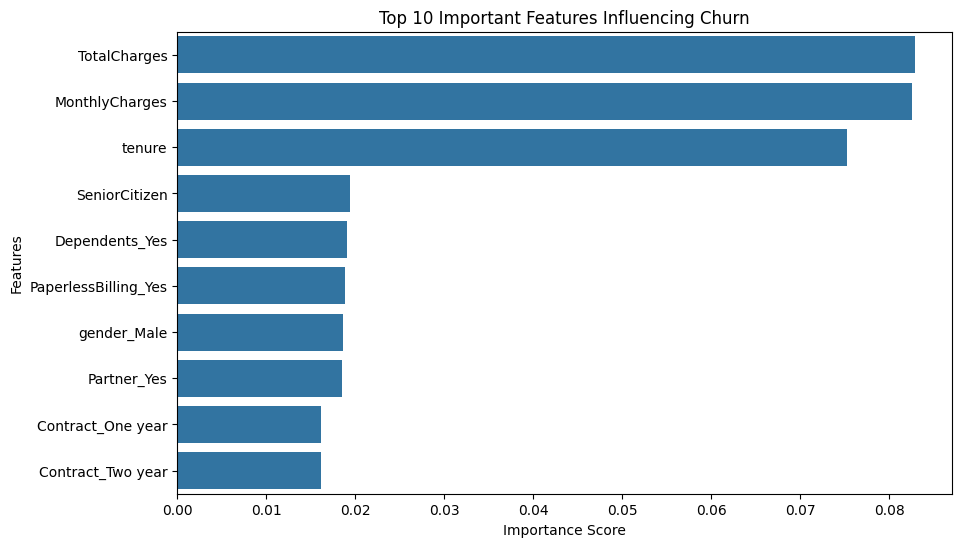

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Important Features Influencing Churn')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

## Fairness and Bias Considerations

Machine learning models can inherit biases from historical data. It is essential to monitor whether predictions disproportionately impact specific demographic groups. Responsible AI practices promote fairness, inclusivity, and regular auditing of model outcomes.


## Ethical Considerations

Organizations must ensure transparency, accountability, and privacy when deploying AI systems. Human oversight and secure handling of customer data are crucial for building trustworthy machine learning applications.


# Conclusion

This project explored the principles of Responsible AI by interpreting a customer churn prediction model using feature importance analysis. The findings emphasized the importance of transparency, fairness, and ethical considerations in machine learning systems.

By understanding the factors influencing predictions and addressing potential biases, organizations can create more responsible and trustworthy AI solutions.
